# Rate-Yield Analysis

This notebook generates plots of rate and yield analysis for cross-electrophile coupling reactions.

1. Data preparation: load NMR yield data and flag alkyl/aryl bromides
2. Bubble plot: ln(k_rel) aryl vs alkyl, bubble size = yield (interactive)
3. Threshold plots: yield vs steric/electronic features by substrate class
   - Alkyl halides: %V_bur threshold
   - Non-heteroaryl halides: %V_bur threshold
   - Heteroaryl halides: HOMO threshold

## 1. Data Preparation and Bubble Plot

C:\Users\haruk\AppData\Local\Temp\ipykernel_15100\2842497643.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["arylBr"]  = df["Ar_smiles"].apply(has_br)
C:\Users\haruk\AppData\Local\Temp\ipykernel_15100\2842497643.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


alkylBr=1: 41  |  arylBr=1: 65
Rows for plotting: 131


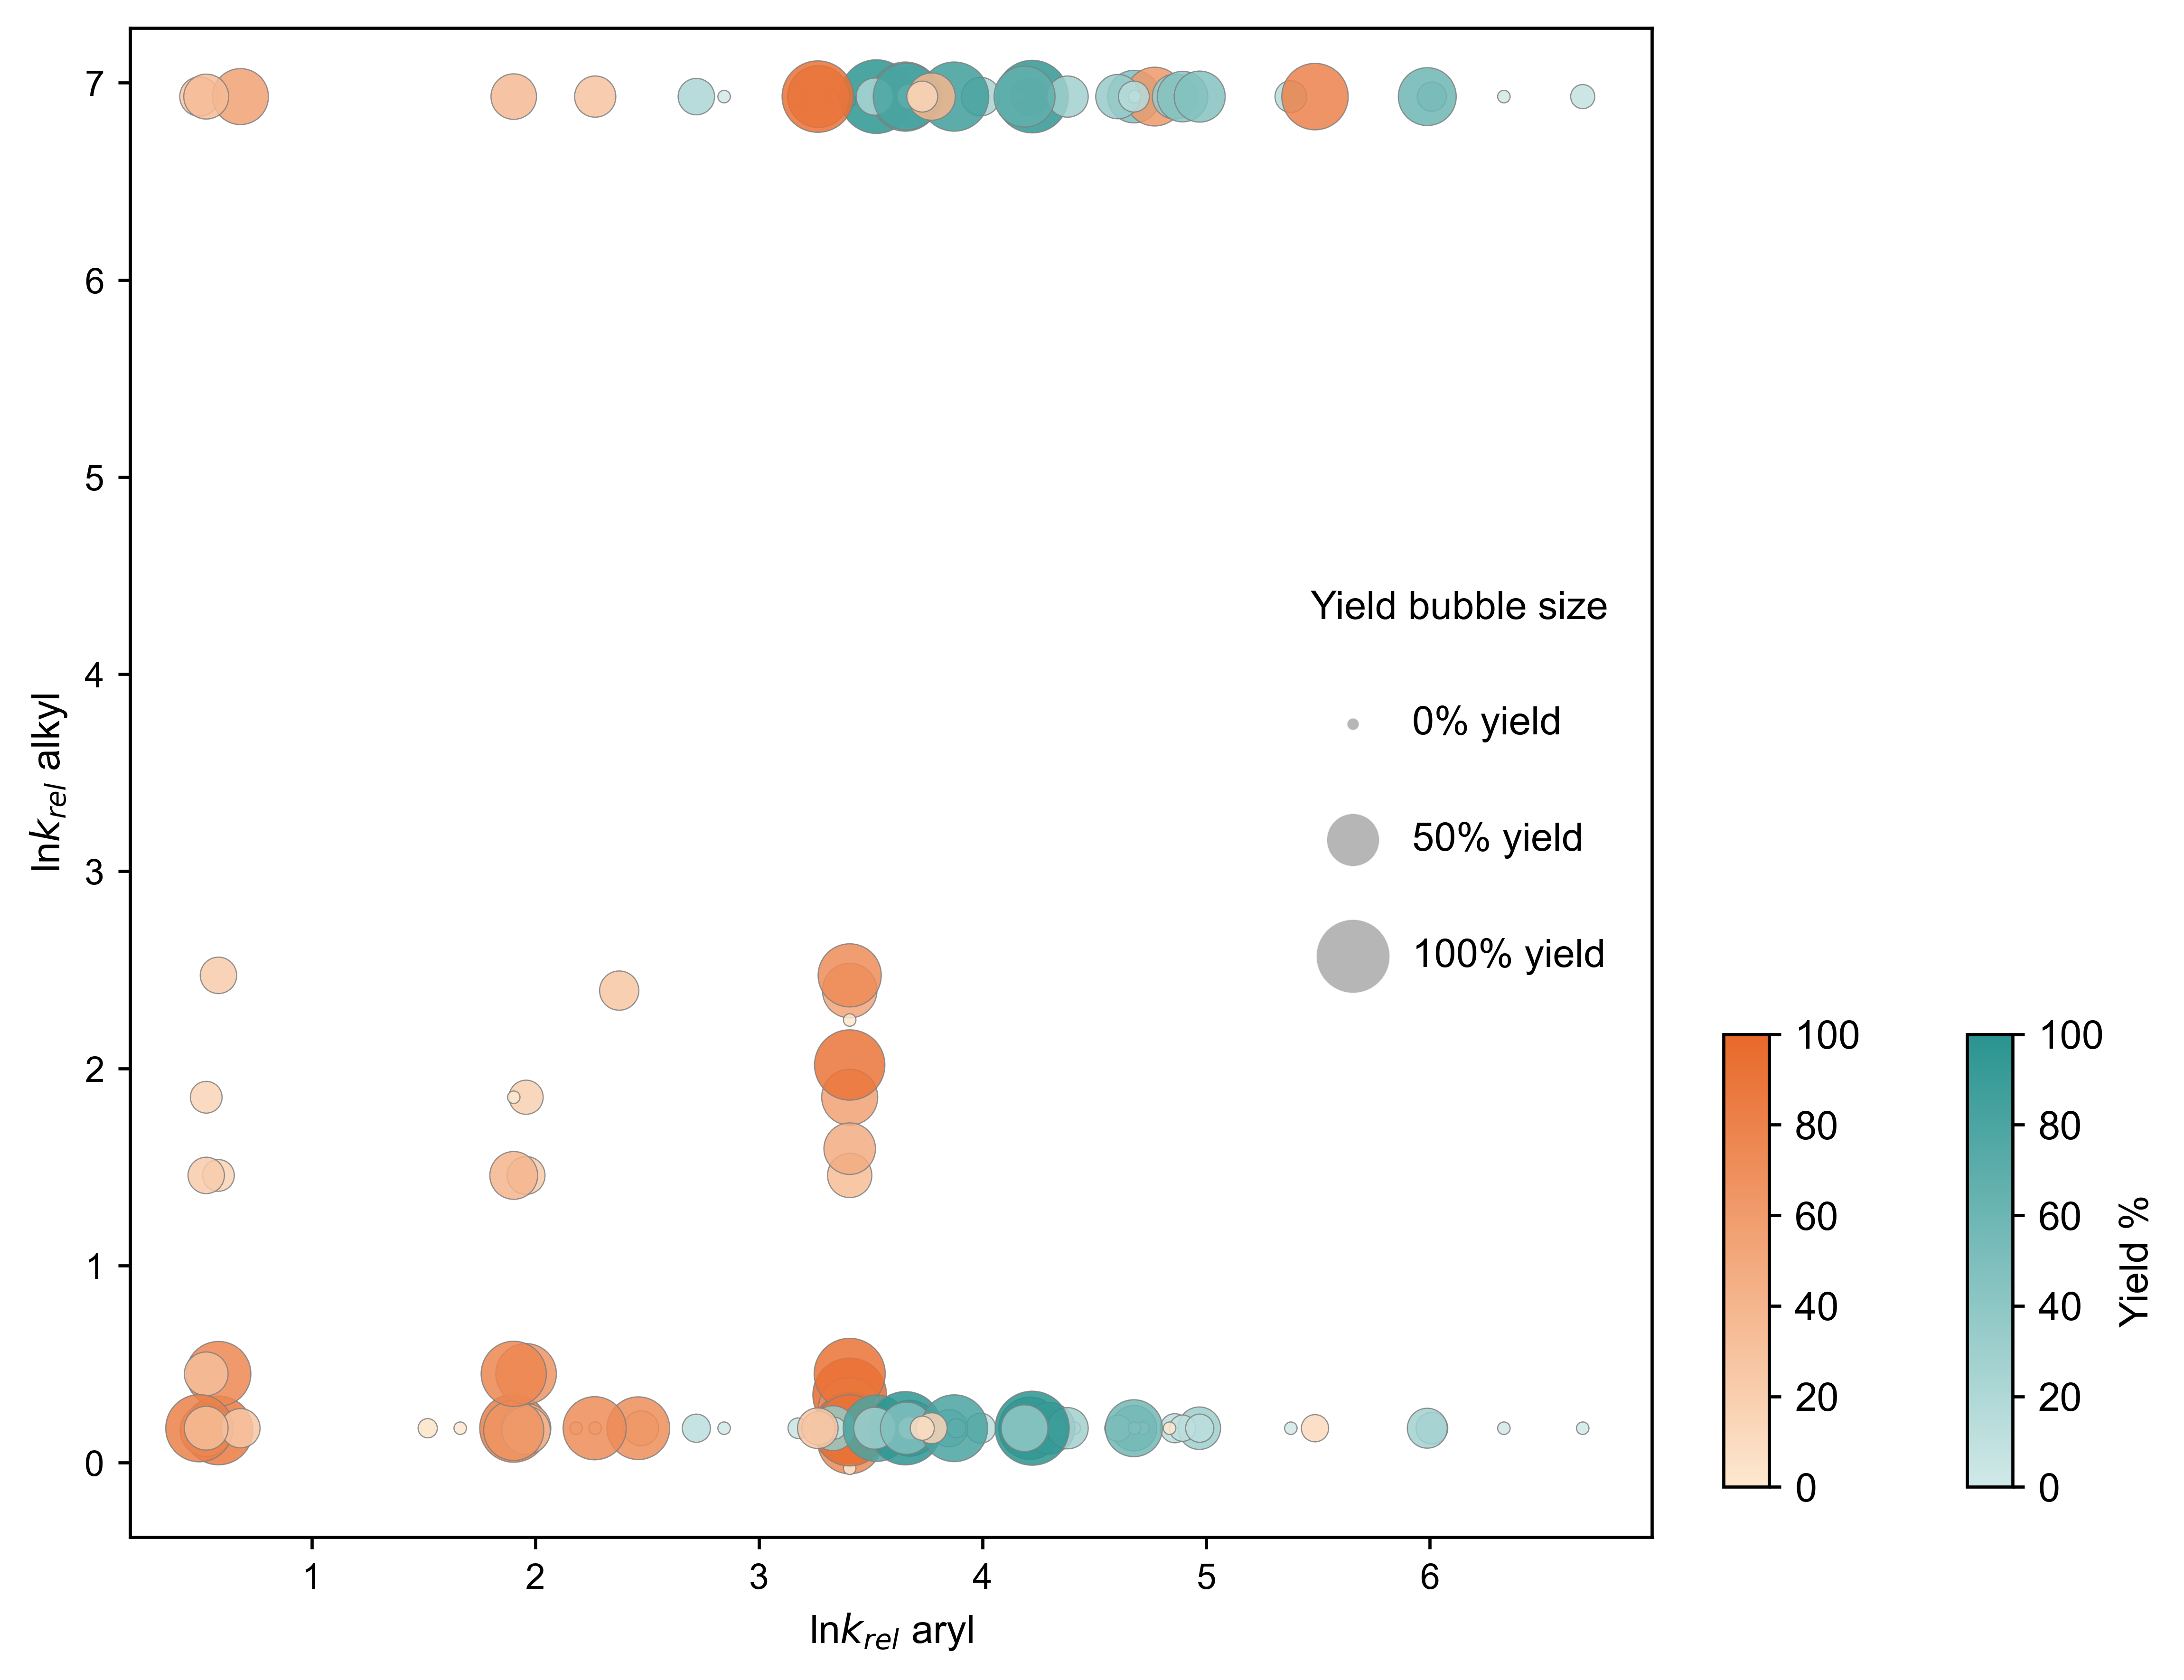

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colorbar as mcolorbar
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from rdkit import Chem

# -----------------------------
# File paths
# -----------------------------
FINAL_FILE = "NMRYields.xlsx"
SHEET = "NMRYields"
# -----------------------------
# Helpers
# -----------------------------
def canonicalize_no_stereo(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return None
        Chem.RemoveStereochemistry(mol)
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except:
        return None

def has_br(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return 0
        return int(any(a.GetAtomicNum() == 35 for a in mol.GetAtoms()))
    except:
        return 0

# -----------------------------
# Load & flag Br
# -----------------------------
df = pd.read_excel(FINAL_FILE, sheet_name=SHEET)

df["alkylBr"] = df["alkyl_smiles"].apply(has_br)
df["arylBr"]  = df["Ar_smiles"].apply(has_br)
print(f"alkylBr=1: {df['alkylBr'].sum()}  |  arylBr=1: {df['arylBr'].sum()}")

plot_df = df.dropna(subset=["Predicted_lnkx_alkyl", "Predicted_lnkx_aryl", "yield"]).copy()
print(f"Rows for plotting: {len(plot_df)}")

# -----------------------------
# Bubble size scaled to yield
# -----------------------------
yield_vals = plot_df["yield"].values
size_min, size_max = 10, 350
sizes = size_min + (yield_vals - yield_vals.min()) / (yield_vals.max() - yield_vals.min() + 1e-9) * (size_max - size_min)

# -----------------------------
# Color: teal = arylBr, orange = alkylBr (or neither)
# intensity driven by yield via colormap
# -----------------------------
norm = mcolors.Normalize(vmin=0, vmax=100)

cmap_teal   = mcolors.LinearSegmentedColormap.from_list("teal_yield",   ["#d0e9e8", "#2a9490"])
cmap_orange = mcolors.LinearSegmentedColormap.from_list("orange_yield", ["#fde8d0", "#e8692a"])

colors = []
for _, row in plot_df.iterrows():
    y = float(row["yield"])
    if row["arylBr"] == 1:
        colors.append(cmap_teal(norm(y)))
    else:
        colors.append(cmap_orange(norm(y)))

# -----------------------------
# JACS single-column style
# -----------------------------
plt.rcParams.update({
    "font.family":    "Arial",
    "font.size":      10,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size":  3,
    "ytick.major.size":  3,
})

fig, ax = plt.subplots(figsize=(6,6), dpi=600)

sc = ax.scatter(
    plot_df["Predicted_lnkx_aryl"],
    plot_df["Predicted_lnkx_alkyl"],
    s=sizes,
    c=colors,
    alpha=0.85,
    linewidths=0.3,
    edgecolors="gray",
)

ax.set_xlabel(r"ln$k_{rel}$ aryl",  fontsize=10)
ax.set_ylabel(r"ln$k_{rel}$ alkyl", fontsize=10)
ax.tick_params(labelsize=9)

# -----------------------------
# Two colorbars — same height, compact
# -----------------------------
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cax1 = inset_axes(ax, width="3%", height="30%", loc="lower right",
                  bbox_to_anchor=(0.25, 0.02, 1, 1), bbox_transform=ax.transAxes)
cax2 = inset_axes(ax, width="3%", height="30%", loc="lower right",
                  bbox_to_anchor=(0.09, 0.02, 1, 1), bbox_transform=ax.transAxes)

sm_teal   = cm.ScalarMappable(cmap=cmap_teal,   norm=norm)
sm_orange = cm.ScalarMappable(cmap=cmap_orange, norm=norm)
sm_teal.set_array([])
sm_orange.set_array([])

cbar1 = fig.colorbar(sm_teal,   cax=cax1)
cbar2 = fig.colorbar(sm_orange, cax=cax2)

for cbar, label in [(cbar1, "Yield %"), (cbar2, "")]:
    cbar.set_label(label, fontsize=10)
    cbar.ax.tick_params(labelsize=10)

# -----------------------------
# Bubble size legend
# -----------------------------
for pct, label in [(0, "0% yield"), (50, "50% yield"), (100, "100% yield")]:
    s = size_min + (pct / 100) * (size_max - size_min)
    ax.scatter([], [], s=s, c="#aaaaaa", alpha=0.85, edgecolors="white",
               linewidths=0.3, label=label)

ax.legend(
    title="Yield bubble size",
    title_fontsize=10,
    fontsize=10,
    frameon=False,
    framealpha=0.9,
    edgecolor="#cccccc",
    loc="center right",
    handletextpad=0.5,
    labelspacing=2,
    borderpad=0.6,
)

plt.tight_layout()
plt.savefig("lnkx_bubble_plot.png", bbox_inches="tight", transparent=True, dpi=600)
plt.show()

In [2]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, ColorBar, LinearColorMapper
from io import BytesIO
import base64

output_notebook()
def smiles_to_base64(smi, size=(200, 200)):
    try:
        from rdkit.Chem import Draw
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return ""
        img = Draw.MolToImage(mol, size=size)
        buf = BytesIO()
        img.save(buf, format="PNG")
        return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()
    except:
        return ""
# Recompute bubble_size in case it wasn't carried over
y = plot_df["yield"].values
size_min, size_max = 6, 40
plot_df["bubble_size"] = size_min + (y - y.min()) / (y.max() - y.min() + 1e-9) * (size_max - size_min)


# Render structure images
plot_df["alkyl_img"] = plot_df["alkyl_smiles"].apply(smiles_to_base64)
plot_df["aryl_img"]  = plot_df["Ar_smiles"].apply(smiles_to_base64)

# Split sources
src_teal   = ColumnDataSource(plot_df[plot_df["arylBr"] == 1].copy())
src_orange = ColumnDataSource(plot_df[plot_df["arylBr"] == 0].copy())

teal_palette   = ["#d0e9e8", "#a8d5d3", "#7bbfbd", "#4fa9a7", "#2a9490", "#1a7a79", "#0f6362", "#064d4c", "#013a3a"]
orange_palette = ["#fde8d0", "#fbd1a2", "#f8b978", "#f59f52", "#f28630", "#d4701e", "#b05a10", "#8c4508", "#6b3204"]

# Color mappers
mapper_teal   = LinearColorMapper(palette=teal_palette,   low=0, high=100)
mapper_orange = LinearColorMapper(palette=orange_palette, low=0, high=100)


# Hover
hover = HoverTool(tooltips="""
    <div style="background:#fefefe; padding:8px; border:1px solid #ccc; border-radius:6px;">
        <div style="display:flex; gap:12px; align-items:center;">
            <div>
                <div style="font-size:11px; font-weight:bold; margin-bottom:4px;">Alkyl</div>
                <img src="@alkyl_img" width="160" height="160"/>
                <div style="font-size:9px; color:#555;">@alkyl_smiles</div>
            </div>
            <div>
                <div style="font-size:11px; font-weight:bold; margin-bottom:4px;">Aryl</div>
                <img src="@aryl_img" width="160" height="160"/>
                <div style="font-size:9px; color:#555;">@Ar_smiles</div>
            </div>
        </div>
        <div style="margin-top:6px; font-size:10px;">
            <b>Yield:</b> @yield%  &nbsp;
            <b>ln(kx) aryl:</b> @Predicted_lnkx_aryl{0.2f}  &nbsp;
            <b>ln(kx) alkyl:</b> @Predicted_lnkx_alkyl{0.2f}
        </div>
    </div>
""")

# Figure
p = figure(
    width=700, height=650,
    title="ln(kx) Aryl vs Alkyl — Bubble size = Yield",
    x_axis_label="ln(kx) aryl",
    y_axis_label="ln(kx) alkyl",
    tools=["pan", "wheel_zoom", "box_zoom", "reset", hover],
    toolbar_location="above",
)

p.scatter("Predicted_lnkx_aryl", "Predicted_lnkx_alkyl", size="bubble_size",
         source=src_teal,   fill_color={"field": "yield", "transform": mapper_teal},
         line_color="white", line_width=0.5, alpha=0.85, legend_label="arylBr")

p.scatter("Predicted_lnkx_aryl", "Predicted_lnkx_alkyl", size="bubble_size",
         source=src_orange, fill_color={"field": "yield", "transform": mapper_orange},
         line_color="white", line_width=0.5, alpha=0.85, legend_label="arylCl")

p.add_layout(ColorBar(color_mapper=mapper_teal,   width=12, height=150,
                      location=(0,0),   title="Yield % (arylBr)",
                      title_text_font_size="9px", major_label_text_font_size="8px"), "right")
p.add_layout(ColorBar(color_mapper=mapper_orange, width=12, height=150,
                      location=(0,180), title="Yield % (alkylBr)",
                      title_text_font_size="9px", major_label_text_font_size="8px"), "right")

p.legend.location = "center"
p.legend.label_text_font_size = "9px"
p.legend.background_fill_alpha = 0.8

show(p)

Loading BokehJS ...

In [3]:
try:
    from rdkit.Chem import Draw
    from rdkit import Chem
    mol = Chem.MolFromSmiles("c1ccccc1")
    img = Draw.MolToImage(mol)
    img
except Exception as e:
    print(f"Error: {e}")

## 2. Threshold Plots by Substrate Class

Decision boundaries were identified using the modeling notebook (https://github.com/SigmanGroup/python-modeling  mattlab_modeling_v6.0.0.ipynb).

interactive plot shows structures for each data point

In [4]:
# ── Reusable scatter plot with decision boundary ───────────────────

def plot_classifier_scatter(df, classification, col_x, vbur_thresh, yield_thresh,
                             filename=None):
    """
    Plots yield vs a feature column for a given classification group,
    with decision boundary lines and yield-colored dots + colorbar.

    Parameters
    ----------
    df             : plot_df (already loaded)
    classification : str  — value in 'classifications' column
    col_x          : str  — feature column name (x-axis)
    vbur_thresh    : float — vertical decision boundary
    yield_thresh   : float — horizontal decision boundary
    filename       : str or None — if None, auto-generated
    """
    scatter_df = df[df["classification"] == classification].copy()
    scatter_df = scatter_df.dropna(subset=[col_x, "yield"])
    print(f"[{classification}] Rows: {len(scatter_df)}  |  "
          f"x: {col_x}  |  thresholds: x={vbur_thresh}, yield={yield_thresh}")

    # ── Color by yield ────────────────────────────────────────────
    cmap = mcolors.LinearSegmentedColormap.from_list("teal_yield", ["#d0f0ee", "#2a9490"])
    norm   = mpl.colors.Normalize(vmin=0, vmax=100)
    colors = cmap(norm(scatter_df["yield"].values))

    fig, ax = plt.subplots(figsize=(3.4,2.5))

    # sc = ax.scatter(scatter_df[col_x], scatter_df["yield"],
    #                 c=scatter_df["yield"], cmap=cmap, norm=norm,
    #                 s=35, alpha=0.85, edgecolors="white", linewidths=0.3, zorder=3)
    sc = ax.scatter(scatter_df[col_x], scatter_df["yield"],
                    c=scatter_df["yield"], cmap=cmap, norm=norm,
                    s=35, alpha=0.9, edgecolors="#4B4949", linewidths=0.4, zorder=3)
    # ── Decision boundaries ───────────────────────────────────────
    ax.axvline(vbur_thresh,  color="#444444", linewidth=0.8, linestyle="--", zorder=2)
    ax.axhline(yield_thresh, color="#444444", linewidth=0.8, linestyle="-", zorder=2)

    # ── Axes ──────────────────────────────────────────────────────
    ax.set_xlabel(col_x.replace("_", " ").replace("alkyl","").replace("aryl","").replace("Boltz","").replace("max",""), fontsize=10, labelpad=2)
    ax.set_ylabel("Yield (%)", fontsize=10, labelpad=-2)
    ax.set_ylim(-5, 105)
    ax.tick_params(labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    plt.tight_layout(pad=0.5)
    fname = filename or f"yield_vs_{classification}.png"
    plt.savefig(fname, dpi=600, transparent=True, bbox_inches="tight")
    plt.show()



In [5]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, Span
import base64
from io import BytesIO

output_notebook()

def mol_to_base64(smiles, size=(200, 150)):
    """Convert SMILES to base64 PNG for embedding in Bokeh tooltip."""
    try:
        from rdkit.Chem import Draw
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return ""
        img = Draw.MolToImage(mol, size=size)
        buf = BytesIO()
        img.save(buf, format="PNG")
        b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
        return f"data:image/png;base64,{b64}"
    except:
        return ""

def plot_classifier_scatter_bokeh(df, classification, col_x, vbur_thresh, yield_thresh):
    scatter_df = df[df["classification"] == classification].copy()
    scatter_df = scatter_df.dropna(subset=[col_x, "yield"]).reset_index(drop=True)
    print(f"[{classification}] Rows: {len(scatter_df)}  — generating structure images...")

    scatter_df["_ar_img"]    = scatter_df["Ar_smiles"].apply(mol_to_base64) if "Ar_smiles" in scatter_df.columns else ""
    scatter_df["_ar"]        = scatter_df["Ar_smiles"].fillna("") if "Ar_smiles" in scatter_df.columns else ""
    scatter_df["_alkyl_img"] = scatter_df["alkyl_smiles"].apply(mol_to_base64) if "alkyl_smiles" in scatter_df.columns else ""
    scatter_df["_alkyl"]     = scatter_df["alkyl_smiles"].fillna("") if "alkyl_smiles" in scatter_df.columns else ""
    scatter_df["_x"]         = scatter_df[col_x].astype(float)
    scatter_df["_yield"]     = scatter_df["yield"].astype(float)

    source = ColumnDataSource(scatter_df[["_x", "_yield", "_ar", "_ar_img", "_alkyl", "_alkyl_img"]])

    p = figure(width=550, height=450,
               title=f"Yield vs {col_x}  [{classification}]",
               toolbar_location="above")

    p.scatter("_x", "_yield", source=source,
              size=9, color="#42668E", alpha=0.75,
              line_color="white", line_width=0.5)

    p.add_layout(Span(location=vbur_thresh, dimension="height",
                      line_color="#810303", line_dash="dashed", line_width=1))
    p.add_layout(Span(location=yield_thresh, dimension="width",
                      line_color="#810303", line_dash="dashed", line_width=1))

    hover = HoverTool(tooltips="""
        <div style="padding:6px; background:white; border:1px solid #ddd; border-radius:4px;">
            <div><b>Aryl halide</b></div>
            <div><img src="@_ar_img" style="width:180px; height:130px;"/></div>
            <div><b>Alkyl halide</b></div>
            <div><img src="@_alkyl_img" style="width:180px; height:130px;"/></div>
            <div style="margin-top:4px;">
                <b>x:</b> @_x{0.000} &nbsp;&nbsp; <b>Yield:</b> @_yield{0.0}%
            </div>
        </div>
    """)
    p.add_tools(hover)

    p.xaxis.axis_label     = col_x.replace("_", " ")
    p.yaxis.axis_label     = "Yield (%)"
    p.outline_line_color   = None
    p.grid.grid_line_alpha = 0.2
    p.y_range.start        = -2
    p.y_range.end          = 105

    show(p)


Loading BokehJS ...

### 2a. Alkyl Halides — Steric Threshold (%V_bur)

[alkyl] Rows: 16  |  x: %Vbur_C_2.5Å_Boltz_alkyl  |  thresholds: x=83.89, yield=20


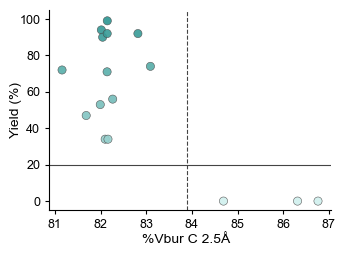

In [6]:
# alkyl — %Vbur threshold
plot_classifier_scatter(plot_df,
    classification = "alkyl",
    col_x          = "%Vbur_C_2.5Å_Boltz_alkyl",
    vbur_thresh    = 83.890,
    yield_thresh   = 20,
    
    filename       = "yield_vs_Vbur_alkyl.png")


*Interactive: hover over points to view substrate structures*

In [7]:
plot_classifier_scatter_bokeh(plot_df,
    classification = "alkyl",
    col_x          = "%Vbur_C_2.5Å_Boltz_alkyl",
    vbur_thresh    = 83.890,
    yield_thresh   = 20)


[alkyl] Rows: 16  — generating structure images...


### 2b. Non-Heteroaryl Halides — Steric Threshold (%V_bur)

[ph] Rows: 24  |  x: %Vbur_X_3.0Å_max_aryl  |  thresholds: x=31.431, yield=20


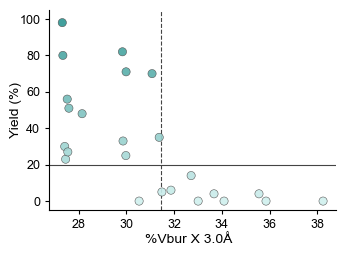

In [8]:
# ph — %Vbur threshold
plot_classifier_scatter(plot_df,
    classification = "ph",
    col_x          = "%Vbur_X_3.0Å_max_aryl",
    vbur_thresh    = 31.431,
    yield_thresh   = 20,
    filename       = "yield_vs_Vbur_ph.png")

*Interactive: hover over points to view substrate structures*

In [9]:
# ph — %Vbur threshold
plot_classifier_scatter_bokeh(plot_df,
    classification = "ph",
    col_x          = "%Vbur_X_3.0Å_max_aryl",
    vbur_thresh    = 31.431,
    yield_thresh   = 20)


[ph] Rows: 24  — generating structure images...


### 2c. Heteroaryl Halides — Electronic Threshold (HOMO)

[het] Rows: 34  |  x: HOMO_Boltz_aryl  |  thresholds: x=-0.294, yield=20


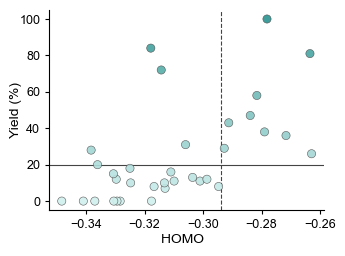

In [10]:
# hetero — HOMO threshold
plot_classifier_scatter(plot_df,
    classification = "het",
    col_x          = "HOMO_Boltz_aryl",
    vbur_thresh    = -0.294,
    yield_thresh   = 20,
    filename       = "yield_vs_homo_hetero.png")

In [11]:
# hetero — HOMO threshold
plot_classifier_scatter_bokeh(plot_df,
    classification = "het",
    col_x          = "HOMO_Boltz_aryl",
    vbur_thresh    = -0.294,
    yield_thresh   = 20)


[het] Rows: 34  — generating structure images...



End of rate-yield analysis script.